In [22]:
import pandas as pd

In [ ]:
arquivo = "ecommerce_novo.xlsx"

df = pd.read_excel(arquivo, sheet_name="RECEITA REAL POR VENDA")

df.head()

,Venda Id,Data Venda,Cliente Id,Canal Id,Canal,Receita Real
0,112,2026-01-22 00:28:41.357672,23,1,Marketplace,14510.06
1,391,2026-01-14 14:30:33.546818,163,1,Marketplace,8271.64
2,199,2025-12-31 16:46:04.12168,44,3,Loja Fisica,8138.96
3,318,2025-09-04 05:47:26.585667,187,1,Marketplace,10940.40
4,62,2025-10-22 06:21:51.260894,26,1,Marketplace,11940.04


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337 entries, 0 to 336
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Venda Id      337 non-null    int64  
 1   Data Venda    337 non-null    object 
 2   Cliente Id    337 non-null    int64  
 3   Canal Id      337 non-null    int64  
 4   Canal         337 non-null    object 
 5   Receita Real  337 non-null    float64
dtypes: float64(1), int64(3), object(2)
memory usage: 15.9+ KB


In [24]:
df["Data Venda"] = pd.to_datetime(df["Data Venda"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337 entries, 0 to 336
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Venda Id      337 non-null    int64         
 1   Data Venda    337 non-null    datetime64[ns]
 2   Cliente Id    337 non-null    int64         
 3   Canal Id      337 non-null    int64         
 4   Canal         337 non-null    object        
 5   Receita Real  337 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 15.9+ KB


In [41]:
faturamento_total = df["Receita Real"].sum()
total_vendas = df["Venda Id"].count()

print("Faturamento total:", faturamento_total)
print("Total de vendas:", total_vendas)

Faturamento total: 3691820.42
Total de vendas: 337


In [17]:
df["Receita Real"].sum()

3691820.42

In [18]:
df.groupby("Canal")["Receita Real"].sum().sort_values(ascending=False)

Canal
Marketplace    1887647.98
Site           1619317.96
Loja Fisica     184854.48
Name: Receita Real, dtype: float64

In [19]:
df.groupby(df["Data Venda"].dt.month)["Receita Real"].sum()

Data Venda
1     639087.72
2     414735.56
3      59403.98
8     395193.36
9     651219.16
10    391515.80
11    574099.56
12    566565.28
Name: Receita Real, dtype: float64

In [20]:
df["Venda Id"].count()

337

In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

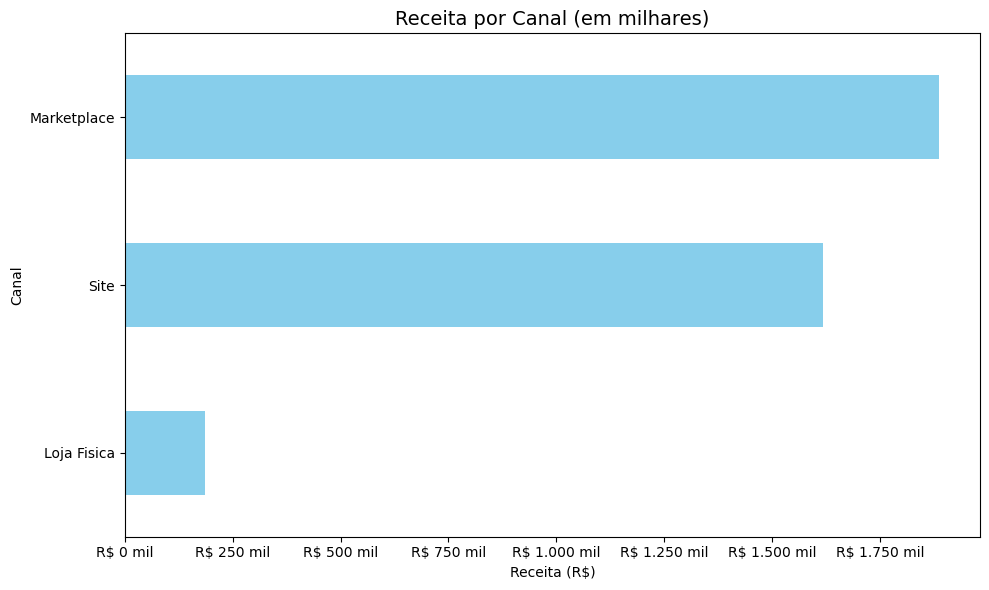

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Agrupamento dos dados
receita_canal = df.groupby("Canal")["Receita Real"].sum().sort_values()

# 2. Criando a figura
fig, ax = plt.subplots(figsize=(10, 6))
receita_canal.plot(kind="barh", ax=ax, color='skyblue')

# 3. FUNÇÃO MÁGICA: Formata os números para "mil"
def format_mil(x, pos):
    return f'R$ {x/1000:,.0f} mil'.replace(',', '.')

# Aplicando o formatador no eixo X
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_mil))

# Ajustes de layout
ax.set_title("Receita por Canal (em milhares)", fontsize=14)
ax.set_xlabel("Receita (R$)")
ax.set_ylabel("Canal")

plt.tight_layout()
plt.show()

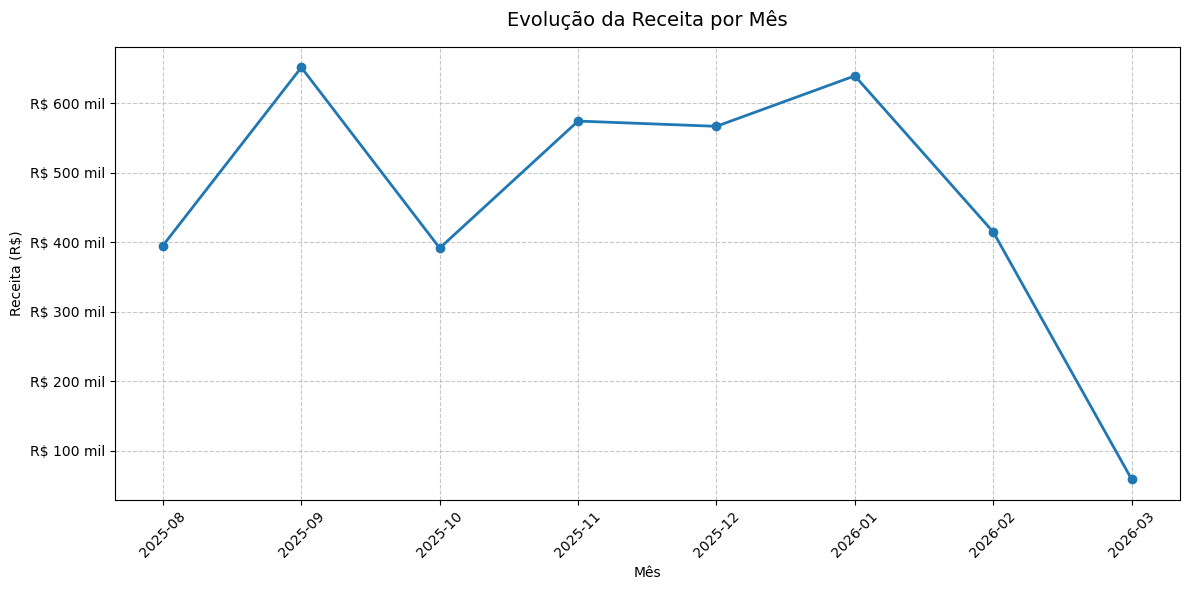

In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Agrupamento (Garantindo que os dados estejam prontos)
receita_mes = df.groupby(df["Data Venda"].dt.to_period("M"))["Receita Real"].sum()
receita_mes.index = receita_mes.index.astype(str)

# 2. Criando o gráfico
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(receita_mes.index, receita_mes.values, marker='o', linestyle='-', linewidth=2)

# 3. FUNÇÃO DE FORMATAÇÃO (Divide por 1000 e adiciona 'mil')
def format_mil(x, pos):
    return f'R$ {x/1000:,.0f} mil'.replace(',', '.')

# Aplicando no eixo Y
ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_mil))

# 4. Ajustes Visuais
ax.set_title("Evolução da Receita por Mês", fontsize=14, pad=15)
ax.set_xlabel("Mês")
ax.set_ylabel("Receita (R$)")
plt.xticks(rotation=45) # Inclina as datas para não encavalarem
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

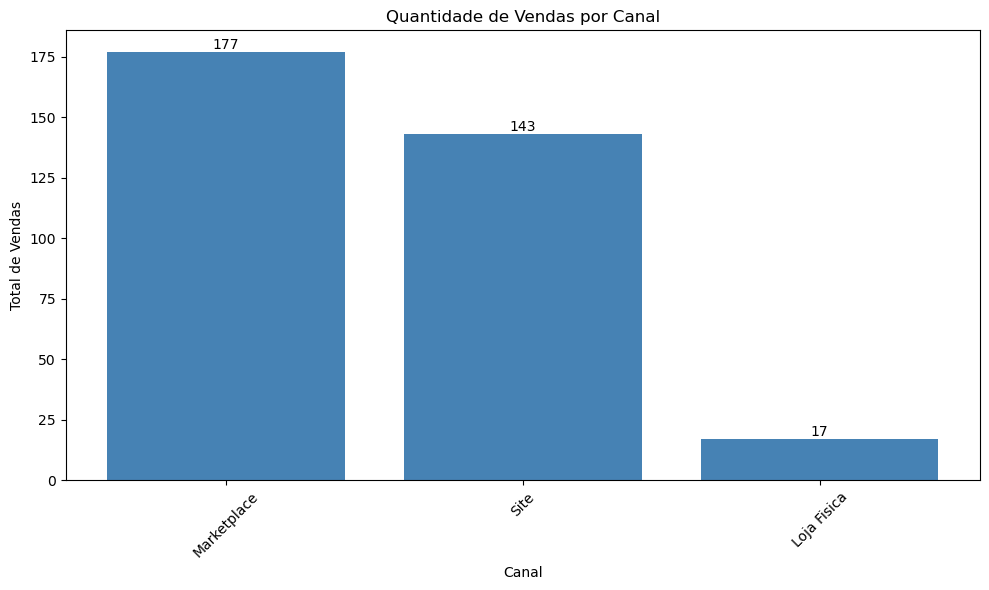

In [42]:
qtd_vendas_canal = df.groupby("Canal")["Canal"].count().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(qtd_vendas_canal.index, qtd_vendas_canal.values, color="steelblue")

ax.bar_label(bars)

ax.set_title("Quantidade de Vendas por Canal")
ax.set_xlabel("Canal")
ax.set_ylabel("Total de Vendas")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()